11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


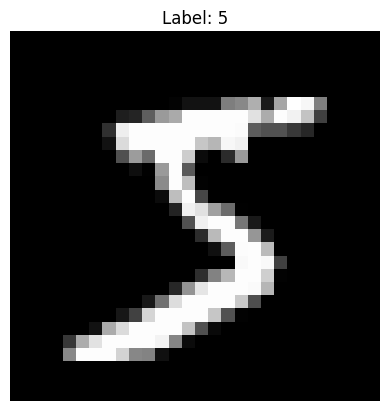

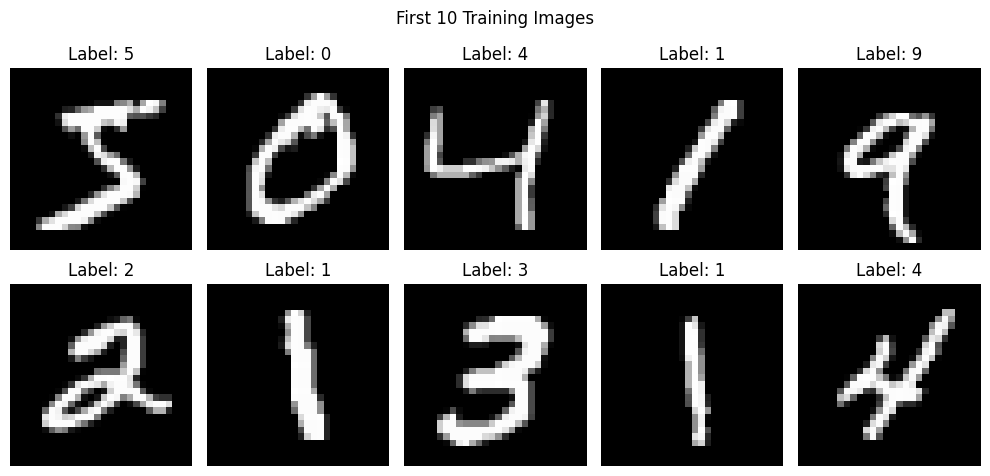

Train and Test image dimensions are consistent.
Padded train shape: (60000, 32, 32, 1)
Padded test shape: (10000, 32, 32, 1)


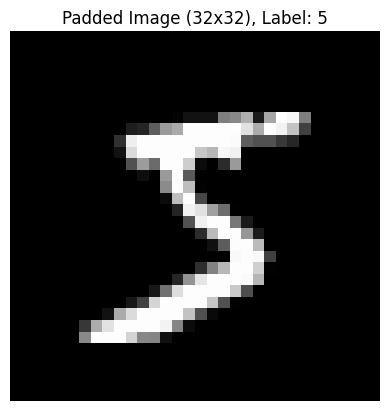

In [1]:
# Exercise 1: MNIST Dataset Analysis and Reshaping

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Inspect shapes
print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

# Display one sample image
plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.axis('off')
plt.show()

# Display first 10 training images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')
plt.suptitle("First 10 Training Images")
plt.tight_layout()
plt.show()

# Check shape consistency
if train_images.shape[1:] == test_images.shape[1:]:
    print("Train and Test image dimensions are consistent.")
else:
    print("Image dimensions are NOT consistent.")

# Reshape to add channel dimension
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

# Pad images to 32x32
pad_width = ((0, 0), (2, 2), (2, 2), (0, 0))
train_images = np.pad(train_images, pad_width, mode='constant')
test_images = np.pad(test_images, pad_width, mode='constant')

print("Padded train shape:", train_images.shape)
print("Padded test shape:", test_images.shape)

# Visualize padded image
plt.imshow(train_images[0].squeeze(), cmap='gray')
plt.title(f"Padded Image (32x32), Label: {train_labels[0]}")
plt.axis('off')
plt.show()


In [2]:
import nltk
from nltk.corpus import names
import random
from nltk import NaiveBayesClassifier, classify

# Download dataset (run once)
nltk.download('names')

# Feature extractor
def gender_features(name):
    return {
        'first_letter': name[0].lower(),
        'last_letter': name[-1].lower(),
        'length': len(name),
        'ends_with_vowel': name[-1].lower() in 'aeiou'
    }

# Load names
labeled_names = (
    [(name, 'male') for name in names.words('male.txt')] +
    [(name, 'female') for name in names.words('female.txt')]
)

random.shuffle(labeled_names)

# Feature set
featuresets = [(gender_features(n), gender) for (n, gender) in labeled_names]

# Train-test split
train_set, test_set = featuresets[500:], featuresets[:500]

# Train classifier
classifier = NaiveBayesClassifier.train(train_set)

# Accuracy
accuracy = classify.accuracy(classifier, test_set)
print("Classifier Accuracy:", accuracy)

# Test predictions
print("Name: Rohit →", classifier.classify(gender_features("Rohit")))
print("Name: Priya →", classifier.classify(gender_features("Priya")))


Classifier Accuracy: 0.736
Name: Rohit → male
Name: Priya → female


[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Unzipping corpora/names.zip.
